# Semantic Segmentation Training Notebook

This notebook builds a clean PyTorch pipeline for the Kaggle aerial imagery semantic segmentation dataset.

Main changes from the earlier version:

- splits at the full-image level, not patch level
- avoids loading all patches into RAM at once
- uses a custom PyTorch `Dataset`
- uses `DataLoader` for batching
- trains a U-Net model with Dice loss and CrossEntropy loss

In [7]:
from pathlib import Path
import os
import json
import random
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import segmentation_models_pytorch as smp
from torchinfo import summary

from tqdm.auto import tqdm

## 2. Set Paths and Training Settings

In [8]:
DATASET_ROOT = Path("DubaiDataset/")
print(f"Dataset Root: {DATASET_ROOT}")

PATCH_SIZE = 256
STRIDE = 256

BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 1e-4
SEED = 42
# NUM_WORKERS = min(4, os.cpu_count() or 1)
NUM_WORKERS = 0 # macOS option

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device: {device}")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

Dataset Root: DubaiDataset
Device: mps


### 2.1 Check the dataset structure

In [9]:
for tile_dir in sorted(DATASET_ROOT.glob("Tile *")):
    image_dir = tile_dir / "images"
    mask_dir = tile_dir / "masks"
    print(tile_dir.name, len(list(image_dir.glob("*"))), len(list(mask_dir.glob("*"))))

Tile 1 9 9
Tile 2 9 9
Tile 3 9 9
Tile 4 9 9
Tile 5 9 9
Tile 6 9 9
Tile 7 9 9
Tile 8 9 9


In [10]:
CLASS_NAMES = ["building", "land", "road", "vegetation", "water", "unlabeled"]

COLOR_TO_CLASS = {
    (60, 16, 152) : 0,
    (132, 41, 246) : 1,
    (110, 193, 228) : 2,
    (254, 221, 58) : 3,
    (226, 169, 41) : 4,
    (155,155,155) : 5
}

IGNORE_INDEX = 5
NUM_CLASSES = 6
print(CLASS_NAMES)
print(f"Ignore Index: {IGNORE_INDEX}")

['building', 'land', 'road', 'vegetation', 'water', 'unlabeled']
Ignore Index: 5


### 2.2: Collect image-mask pairs

Why pair images and masks first?

Each training example in semantic segmentation is a **(image, mask)** pair: the
image is the input, and the mask is the correct per-pixel label the model learns
to predict. The images and masks live in separate folders and use different
extensions (`.jpg` vs `.png`), so I build the correspondence explicitly.

Collecting the pairs upfront lets us:

- **keep each image matched to its correct mask** — they can never drift apart later,
- **drop any image with no matching mask** (unusable for supervised training),
- **split at the image level** so patches from one image don't leak across train/val,
- **feed a clean list straight into the PyTorch `Dataset`**, which loads each pair on demand.


In [11]:
def collect_image_mask_pairs(dataset_root):
    pairs = []

    for tile_dir in sorted(dataset_root.glob("Tile *")):
        image_dir = tile_dir / "images"
        mask_dir = tile_dir / "masks"

        for image_path in sorted(image_dir.glob("*.jpg")):
            mask_path = mask_dir / image_path.with_suffix(".png").name
            if mask_path.exists():
                pairs.append((image_path, mask_path))

    return pairs


pairs = collect_image_mask_pairs(DATASET_ROOT)
print(f"Total full images: {len(pairs)}")
print(pairs[:3])

Total full images: 72
[(PosixPath('DubaiDataset/Tile 1/images/image_part_001.jpg'), PosixPath('DubaiDataset/Tile 1/masks/image_part_001.png')), (PosixPath('DubaiDataset/Tile 1/images/image_part_002.jpg'), PosixPath('DubaiDataset/Tile 1/masks/image_part_002.png')), (PosixPath('DubaiDataset/Tile 1/images/image_part_003.jpg'), PosixPath('DubaiDataset/Tile 1/masks/image_part_003.png'))]


### 2.3 Visual Check of one iamge and one mask

Image Shape: (544, 509, 3)
Mask Shape: (544, 509, 3)


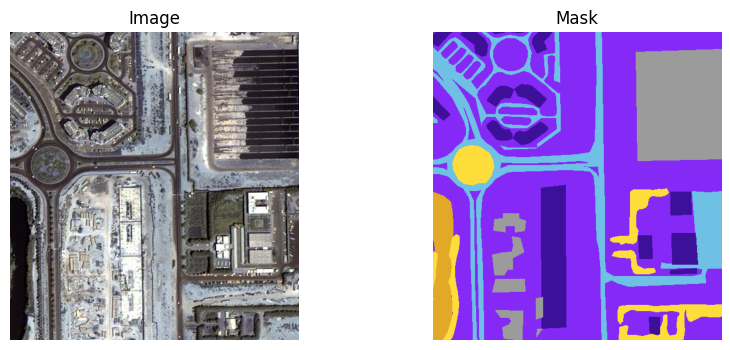

In [12]:
idx = random.randint(0, len(pairs) - 1)
img_path, mask_path = pairs[idx]
image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB) # matplotlibs and plt.imshow read RGB
mask = cv2.cvtColor(cv2.imread(str(mask_path)), cv2.COLOR_BGR2RGB)

print(f"Image Shape: {image.shape}")
print(f"Mask Shape: {mask.shape}")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")
plt.axis(False)

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")
plt.axis(False)

plt.show()


### 2.4 Convert RGB mask to class-index mask
- The mask files are RGB images where each color represents a semantic class.
- Neural networks do not train directly on these RGB colors. For segmentation, the target mask should be a 2D array where each pixel contains a class index: for example, 0 = building, 1 = land, 2 = road, etc.
- This function converts each RGB mask pixel into its corresponding class ID.
- Any pixel color that is not found in color_to_class is assigned ignore_index,so the loss function can ignore unknown or unlabeled pixels during training.

In [13]:
def rgb_mask_to_class_mask(mask_rgb, color_to_class, ignore_index = IGNORE_INDEX):
    h,w,_ = mask_rgb.shape
    class_mask = np.full((h,w), ignore_index, dtype=np.uint8) # creates a h x w array fill with ignore_index value

    for color, class_idx in color_to_class.items():
        matches = np.all(mask_rgb == np.array(color), axis = -1)
        class_mask[matches] = class_idx
    
    return class_mask

Unique class values: [0 1 2 3 4 5]
Image Shape: (544, 509, 3)
Mask Shape: (544, 509, 3)
Mask ID Shape: (544, 509)


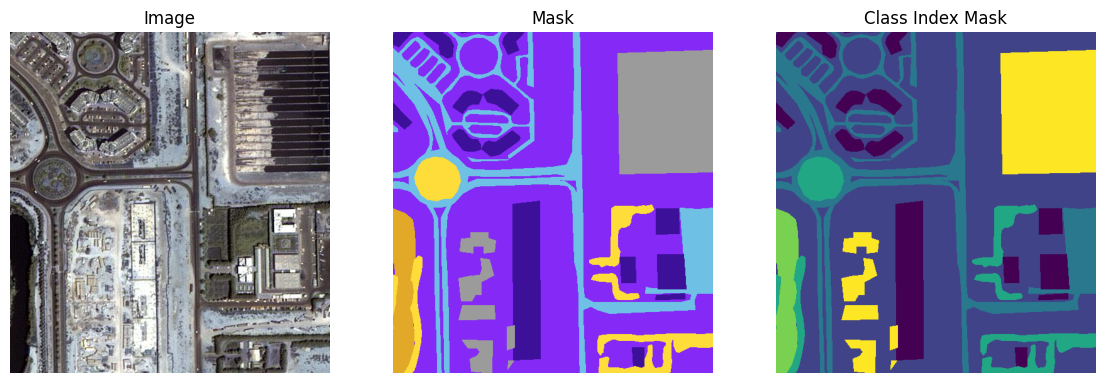

In [14]:
sample_class_mask = rgb_mask_to_class_mask(mask, COLOR_TO_CLASS, IGNORE_INDEX)
print("Unique class values:", np.unique(sample_class_mask))

print(f"Image Shape: {image.shape}")
print(f"Mask Shape: {mask.shape}")
print(f"Mask ID Shape: {sample_class_mask.shape}")

plt.figure(figsize=(14,10))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis(False)

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Mask")
plt.axis(False)

plt.subplot(1,3,3)
plt.imshow(sample_class_mask)
plt.title("Class Index Mask")
plt.axis("off")
plt.show()

### 2.5: Split at the full-image level
- This prevents leakage between train and validation patches

In [15]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size = 0.2,
    random_state = SEED
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=SEED
)

print("Train full images", len(train_pairs))
print("Val full images", len(val_pairs))
print("Test full images", len(test_pairs))

Train full images 57
Val full images 7
Test full images 8


## 3. Build Patch Index

Instead of training the model on each full satellite image at once, I split every image and mask pair into smaller fixed-size patches, such as `256 x 256`.

This makes training more memory-friendly because the model only sees one small crop at a time instead of a large full-resolution image. It also creates more training samples from the same dataset.

Each patch record stores:

- the image path
- the mask path
- the `(x, y)` location of the patch inside the full image
- the patch size


In [16]:
def build_patch_index(pairs, patch_size = 256, stride = 256):
    patch_records = []
    
    for img_path, mask_path in pairs:
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if image is None:
            continue
        
        h,w,_ = image.shape
        usable_h = (h // patch_size) * patch_size # // floor
        usable_w = (w // patch_size) * patch_size

        for y in range(0, usable_h - patch_size + 1, stride):
            for x in range(0, usable_w - patch_size + 1, stride):
                patch_records.append({
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "x": x,
                    "y": y,
                    "patch_size": patch_size
                })
    return patch_records

train_records = build_patch_index(train_pairs, PATCH_SIZE, STRIDE)
val_records = build_patch_index(val_pairs, PATCH_SIZE, STRIDE)
test_records = build_patch_index(test_pairs, PATCH_SIZE, STRIDE)

print("Train patches:", len(train_records))
print("Val patches:", len(val_records))
print("Test patches:", len(test_records))

Train patches: 1102
Val patches: 49
Test patches: 154


## 4. Custom PyTorch Dataset

In [17]:
train_records

[{'img_path': PosixPath('DubaiDataset/Tile 3/images/image_part_005.jpg'),
  'mask_path': PosixPath('DubaiDataset/Tile 3/masks/image_part_005.png'),
  'x': 0,
  'y': 0,
  'patch_size': 256},
 {'img_path': PosixPath('DubaiDataset/Tile 3/images/image_part_005.jpg'),
  'mask_path': PosixPath('DubaiDataset/Tile 3/masks/image_part_005.png'),
  'x': 256,
  'y': 0,
  'patch_size': 256},
 {'img_path': PosixPath('DubaiDataset/Tile 3/images/image_part_005.jpg'),
  'mask_path': PosixPath('DubaiDataset/Tile 3/masks/image_part_005.png'),
  'x': 0,
  'y': 256,
  'patch_size': 256},
 {'img_path': PosixPath('DubaiDataset/Tile 3/images/image_part_005.jpg'),
  'mask_path': PosixPath('DubaiDataset/Tile 3/masks/image_part_005.png'),
  'x': 256,
  'y': 256,
  'patch_size': 256},
 {'img_path': PosixPath('DubaiDataset/Tile 7/images/image_part_003.jpg'),
  'mask_path': PosixPath('DubaiDataset/Tile 7/masks/image_part_003.png'),
  'x': 0,
  'y': 0,
  'patch_size': 256},
 {'img_path': PosixPath('DubaiDataset/Tile

In [18]:
from os import pathconf
class DubaiSegmentationDataset(Dataset):
    def __init__(self, patch_records, color_to_class, ignore_index = 5, augment=False):
        self.patch_records = patch_records
        self.color_to_class = color_to_class
        self.ignore_index = ignore_index
        self.augment = augment
    
    def __len__(self):
        return len(self.patch_records)

    def __getitem__(self, idx):
        record = self.patch_records[idx]

        img_path = record['img_path']
        mask_path = record['mask_path']
        x = record['x']
        y = record['y']
        patch_size = record['patch_size']

        image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB) 
        mask = cv2.cvtColor(cv2.imread(str(mask_path)), cv2.COLOR_BGR2RGB) # color class is in RGB

        image_patch = image[y:y+patch_size, x:x+patch_size]
        mask_patch = mask[y:y+patch_size, x:x+patch_size]

        class_mask = rgb_mask_to_class_mask(mask_rgb=mask_patch,
                                            color_to_class=self.color_to_class,
                                            ignore_index=self.ignore_index)

        if self.augment:
            if random.random() < 0.5:
                image_patch = np.fliplr(image_patch).copy()
                class_mask = np.fliplr(class_mask).copy()

            if random.random() < 0.5:
                image_patch = np.flipud(image_patch).copy()
                class_mask = np.flipud(class_mask).copy()

        image_patch = image_patch.astype(np.float32) / 255.0  # Normalized
        image_patch = torch.from_numpy(image_patch).permute(2,0,1).float() # PyTorch shape: [C,H,W]
        class_mask = torch.from_numpy(class_mask).long()

        return image_patch, class_mask

## 5. Create Datasets and Dataloaders

In [19]:
train_dataset = DubaiSegmentationDataset(
    patch_records=train_records,
    color_to_class=COLOR_TO_CLASS,
    ignore_index=IGNORE_INDEX,
)

val_dataset = DubaiSegmentationDataset(
    val_records,
    COLOR_TO_CLASS,
    IGNORE_INDEX,
    augment=False
)

test_dataset = DubaiSegmentationDataset(
    test_records,
    COLOR_TO_CLASS,
    IGNORE_INDEX,
    augment=False
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

test_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

### 5.1 Check One Batch

In [20]:
images, masks = next(iter(train_loader))

print(f"Image Shape: {images.shape}")
print(f"Mask shape: {masks.shape}")
print(f"Unique labels: {torch.unique(masks)}")

Image Shape: torch.Size([16, 3, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Unique labels: tensor([0, 1, 2, 3, 4, 5])


{'img_path': PosixPath('DubaiDataset/Tile 7/images/image_part_003.jpg'), 'mask_path': PosixPath('DubaiDataset/Tile 7/masks/image_part_003.png'), 'x': 512, 'y': 1024, 'patch_size': 256}
(tensor([0, 1, 2, 3]), tensor([25172, 16660,   569, 23135]))


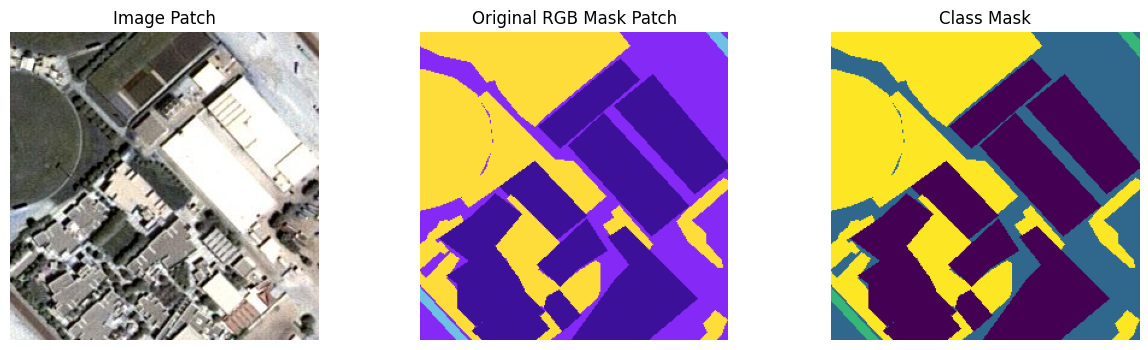

In [21]:
idx = 34
sample_img, sample_mask = train_dataset[idx]

print(train_records[idx])
print(torch.unique(sample_mask, return_counts=True))

record = train_records[idx]

raw_mask = cv2.cvtColor(
    cv2.imread(str(record["mask_path"])),
    cv2.COLOR_BGR2RGB
)

x, y, ps = record["x"], record["y"], record["patch_size"]
raw_mask_patch = raw_mask[y:y+ps, x:x+ps]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample_img.permute(1, 2, 0).numpy())
plt.title("Image Patch")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_mask_patch)
plt.title("Original RGB Mask Patch")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_mask.numpy())
plt.title("Class Mask")
plt.axis("off")

plt.show()

## 6. Build The Model

In [22]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

summary(model, input_size=(1,3, PATCH_SIZE, PATCH_SIZE), device=device.type)

Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [1, 6, 256, 256]          --
├─ResNetEncoder: 1-1                          [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                            [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 128, 128]         128
│    └─ReLU: 2-3                              [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                         [1, 64, 64, 64]           --
│    └─Sequential: 2-5                        [1, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                   [1, 64, 64, 64]           73,984
│    └─Sequential: 2-6                        [1, 128, 32, 32]          --
│    │    └─BasicBlock: 3-4                   [1, 128, 32, 32]          230,144

### 6.1 Loss & Optimizer

In [23]:
dice_loss = smp.losses.DiceLoss(
    mode = "multiclass",
    ignore_index=IGNORE_INDEX
)

ce_loss = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def total_loss_fn(logits, target):
    return dice_loss(logits, target) + ce_loss(logits, target)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

### 6.2 Metrics

In [24]:
def pixel_accuracy(logits, target, ignore_index=IGNORE_INDEX):
    pred = torch.argmax(logits, dim=1) # logits to label
    valid = target != ignore_index
    correct = (pred==target) & valid

    return correct.sum().float() / valid.sum().float()

In [25]:
def mean_iou(logits, target, num_classes=6, ignore_index=5):
    pred = torch.argmax(logits, dim=1)
    ious = []

    valid = target != ignore_index

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_c = (pred == cls) & valid
        target_c = (target == cls) & valid

        intersection = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()

        if union > 0:
            ious.append((intersection + 1.0) / (union + 1.0))

    if len(ious) == 0:
        return torch.tensor(0.0, device=logits.device)

    return torch.mean(torch.stack(ious))

In [26]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, dtype = torch.float32)
        masks = masks.to(device, dtype=torch.long)

        # 1. Forward Pass
        logits = model(images)

        # 2. Calculate loss 
        loss = total_loss_fn(logits, masks)

        # 3. Optimizer zero grad
        optimizer.zero_grad(set_to_none=True) # memory efficient
        
        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [27]:
def evaluate(model, loader, device, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0

    with torch.inference_mode():
        for images, masks in loader:
            images = images.to(device, dtype = torch.float32)
            masks = masks.to(device, dtype = torch.long)

            logits = model(images)
            loss = total_loss_fn(logits, masks)

            running_loss += loss.item()
            running_iou += mean_iou(logits, masks, num_classes, ignore_index).item()
            running_acc += pixel_accuracy(logits, masks,ignore_index).item()
        
        n = len(loader)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "acc": running_acc / n
    }        

### 6.3 Training Loop

In [128]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_acc": []
}
best_iou = -1.0
patience = 8
epochs_no_improve = 0

In [129]:
for epoch in tqdm(range(NUM_EPOCHS)):
    train_loss = train_one_epoch(model,train_loader,optimizer,device)
    val_metrics = evaluate(model, val_loader, device, NUM_CLASSES, IGNORE_INDEX)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_acc"].append(val_metrics["acc"])

    if val_metrics["iou"] > best_iou:
        best_iou = val_metrics["iou"]
        epochs_no_improve = 0
        torch.save(model.state_dict(), "models/pytorch_model.pth")
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f} | "
        f"Val Acc: {val_metrics['acc']:.4f}"
    )

    if epochs_no_improve >= patience:
        print("Early stopping")
        break

  3%|▎         | 1/30 [03:47<1:50:09, 227.90s/it]

Epoch 1/30 | Train Loss: 1.7183 | Val Loss: 1.5837 | Val IoU: 0.3893 | Val Acc: 0.6262


  7%|▋         | 2/30 [06:04<1:21:21, 174.35s/it]

Epoch 2/30 | Train Loss: 1.2262 | Val Loss: 1.3328 | Val IoU: 0.4662 | Val Acc: 0.7120


 10%|█         | 3/30 [08:22<1:10:53, 157.53s/it]

...

Epoch 19/30 | Train Loss: 0.2691 | Val Loss: 0.7590 | Val IoU: 0.6285 | Val Acc: 0.8115


 67%|██████▋   | 20/30 [45:50<20:45, 124.59s/it]

Epoch 20/30 | Train Loss: 0.2635 | Val Loss: 0.8598 | Val IoU: 0.6128 | Val Acc: 0.7936


 67%|██████▋   | 20/30 [47:49<23:54, 143.46s/it]

Epoch 21/30 | Train Loss: 0.2542 | Val Loss: 0.7380 | Val IoU: 0.6379 | Val Acc: 0.8118
Early stopping


### 6.4 Plot Training History

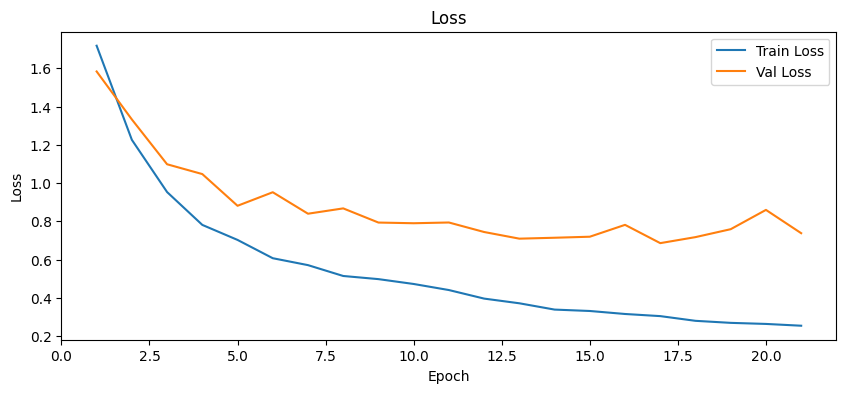

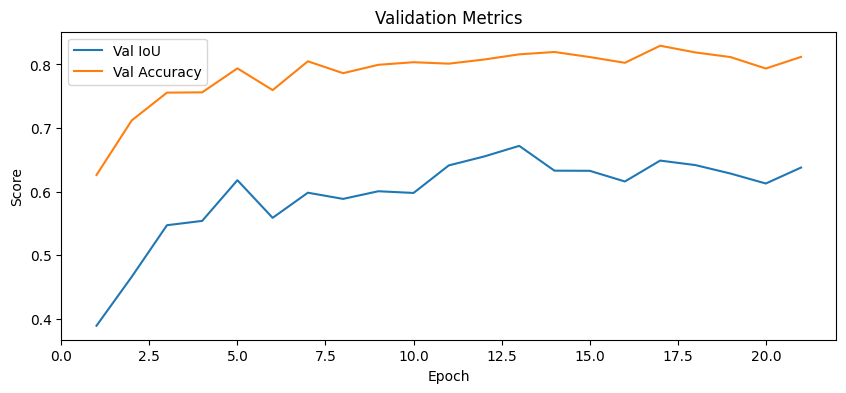

In [130]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["val_iou"], label="Val IoU")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Validation Metrics")
plt.show()

## 7. Load The Model and Test

In [6]:
pytorch_model = smp.Unet(
    encoder_name = "resnet34",
    encoder_weights = None,
    in_channels = 3,
    classes = NUM_CLASSES,
).to(device)

pytorch_model.load_state_dict(torch.load("./models/pytorch_model.pth", map_location=device))

<All keys matched successfully>

In [28]:
test_metrics = evaluate(pytorch_model, test_loader, device, NUM_CLASSES, IGNORE_INDEX)
print(test_metrics)

{'loss': 0.33455914864991454, 'iou': 0.7725926028645557, 'acc': 0.9360475177350251}


## 7. Show Predictions

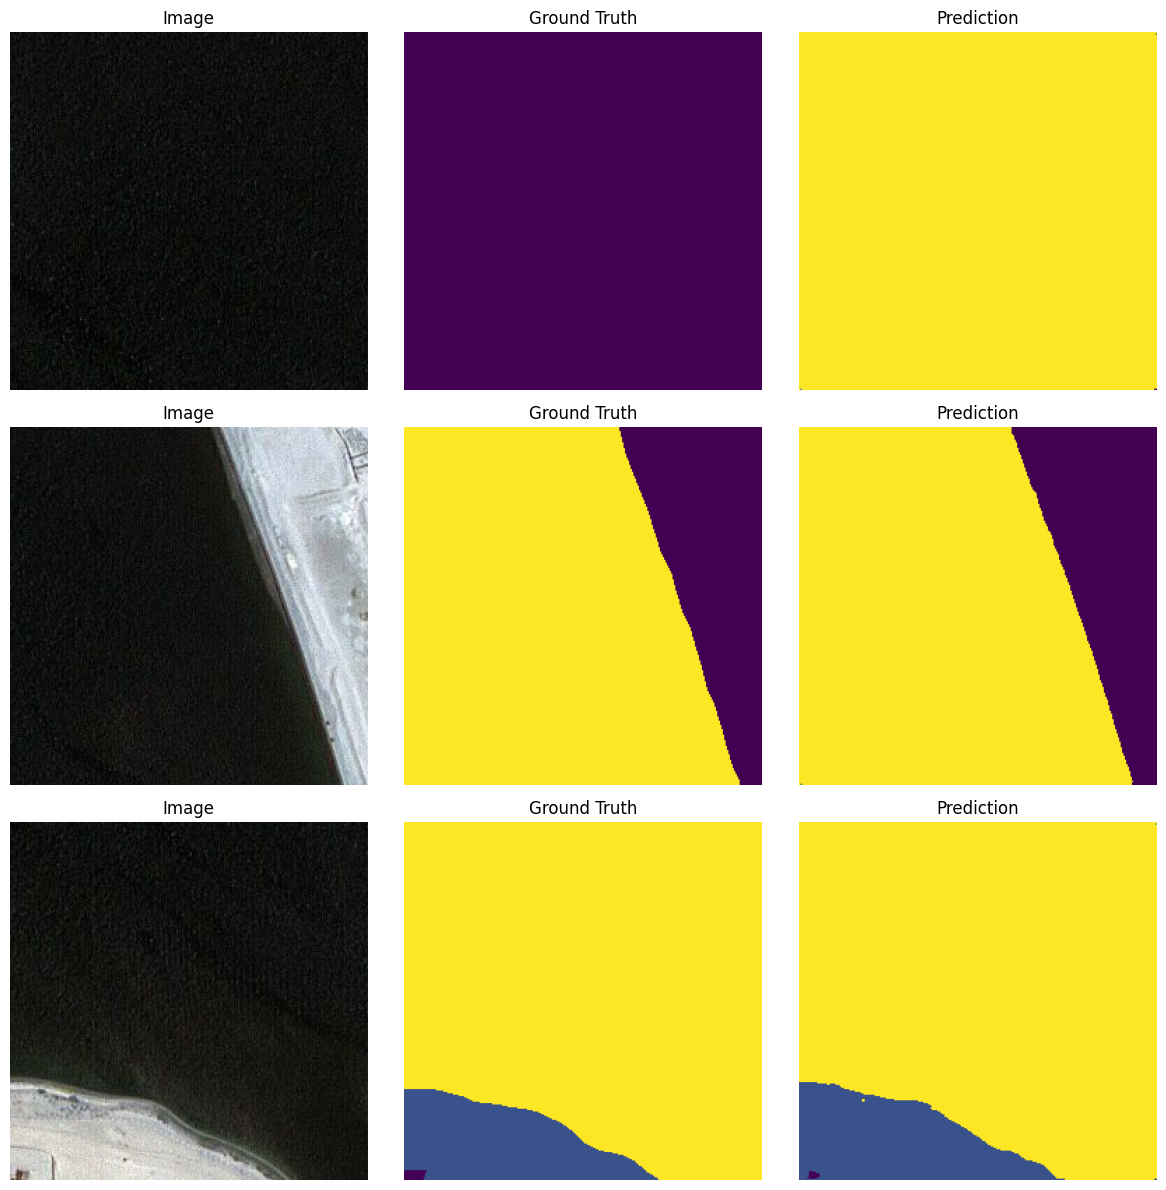

In [ ]:
@torch.no_grad()
def show_predictions(model, dataset, num_samples=3):
    model.eval()

    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(12, 4 * num_samples))

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]

        x = image.unsqueeze(0).to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.numpy()

        plt.subplot(num_samples, 3, row * 3 + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, row * 3 + 2)
        plt.imshow(mask_np)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, row * 3 + 3)
        plt.imshow(pred)
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(pytorch_model, test_dataset, num_samples=3)